# GeoBench FieldsOfTheWorld

## Intro

Fields of The World (FoTW) [(Kerner at al. 2024)](https://arxiv.org/abs/2409.16252) is a comprehensive global dataset for agricultural field boundary delineation using multi-temporal satellite imagery. The dataset provides field boundary annotations across diverse agricultural landscapes worldwide, enabling automated field mapping for precision agriculture, crop monitoring, and food security applications.

## Dataset Characteristics

- **Modalities**: 
  - Multi-temporal Sentinel-2 optical imagery
- **Spatial Resolution**: 10m (resampled from native Sentinel-2 bands)
- **Temporal Resolution**: Multi-temporal composites across growing seasons
- **Spectral Bands**: 
  - S2: 10 bands (B02, B03, B04, B05, B06, B07, B08, B8A, B11, B12)
- **Image Dimensions**: 256x256 pixels per patch
- **Labels**: Agricultural field boundary segmentation
  - Binary segmentation (field boundaries vs. non-boundaries)
  - Precise boundary delineation for field mapping
- **Geographic Distribution**: Global coverage across major agricultural regions
- **Temporal Coverage**: Multiple growing seasons (2019-2021)


## GeoBenchV2 Processing Pipeline

### Preprocessing Steps

1. **Sample filtering**:
   - Dataset was filtered to only contain data that is released under open CC-BY license, namely:
      "austria", "brazil", "corsica", "denmark", "estonia", "finland", "france", "india","kenya", "luxembourg","netherlands", "rwanda", "slovakia", "spain", "vietnam"

2. **Split Generation**:
   - Use the existing train/val/test splits from the dataset

3. **Dataset Subsampling**:
    - The final version consists of
        - 4,000 training samples
        - 1,000 validation samples
        - 2,000 test samples

## References

1. Kerner, H., Chaudhari, S., Ghosh, A., Robinson, C., Ahmad, A., Choi, E., Jacobs, N., Holmes, C., Mohr, M., Dodhia, R. and Ferres, J.M.L., 2025, April. Fields of the world: A machine learning benchmark dataset for global agricultural field boundary segmentation. In Proceedings of the AAAI Conference on Artificial Intelligence (Vol. 39, No. 27, pp. 28151-28159).

2. Fields of The World Website: https://fieldsofthe.world/


In [1]:
import os
from pathlib import Path

import torch

from geobench_v2.datamodules import GeoBenchFieldsOfTheWorldDataModule
from geobench_v2.datasets import GeoBenchFieldsOfTheWorld
from geobench_v2.datasets.normalization import SatMAENormalizer, ZScoreNormalizer
from geobench_v2.datasets.visualization_util import (
    compare_normalization_methods,
    compute_batch_histograms,
    plot_batch_histograms,
    plot_channel_histograms,
    visualize_segmentation_target_statistics,
)

%load_ext autoreload
%autoreload 2

In [2]:
DATA_ROOT = Path("../../data/fotw")

STATS_SATMAE_PATH = os.path.join(DATA_ROOT, "fotw_stats_satmae.json")
STATS_CLIP_RESCALE_PATH = os.path.join(DATA_ROOT, "fotw_stats_clip_rescale.json")

In [3]:
band_order = GeoBenchFieldsOfTheWorld.band_default_order

datamodule = GeoBenchFieldsOfTheWorldDataModule(
    img_size=256,
    batch_size=4,
    num_workers=4,
    root=DATA_ROOT,
    band_order=band_order,
    data_normalizer=torch.nn.Identity(),  # we do custom normalization in the tutorial
)
datamodule.setup("fit")

Using provided pre-initialized normalizer instance: Identity
Using provided pre-initialized normalizer instance: Identity


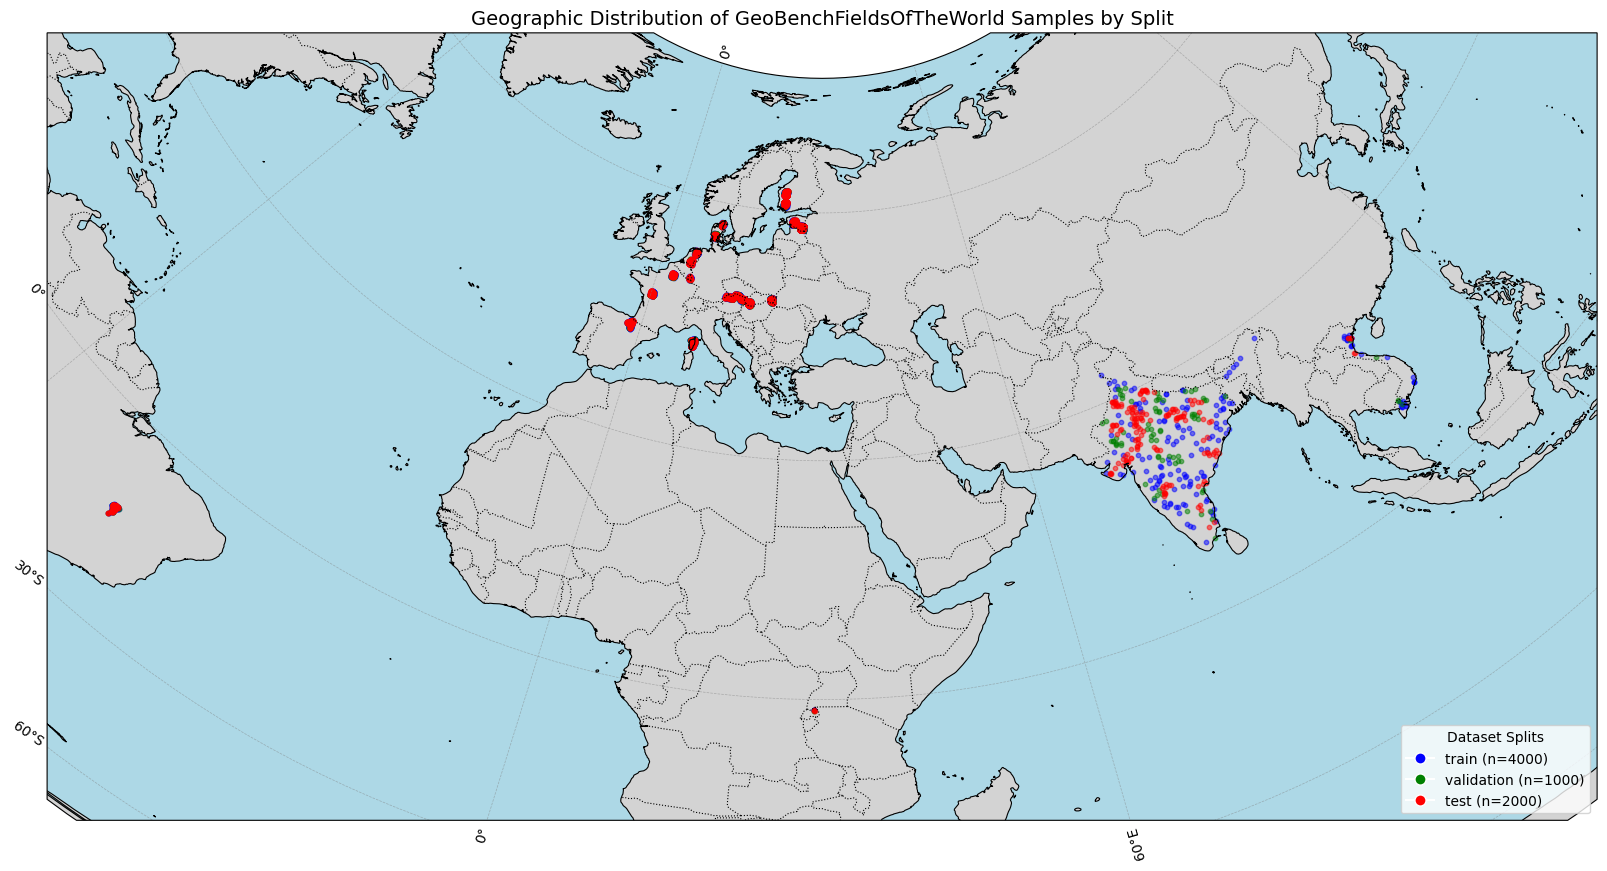

In [4]:
sample_dist_fig = datamodule.visualize_geospatial_distribution()

## Dataset Statistics

Computed over the training dataset.

### Image Statistics

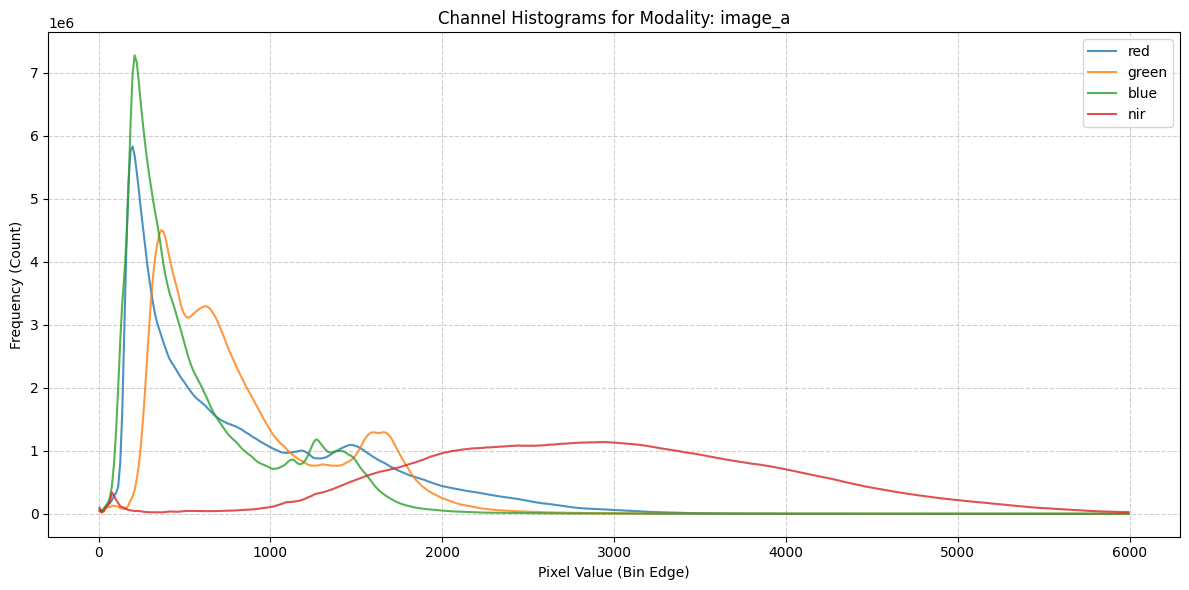

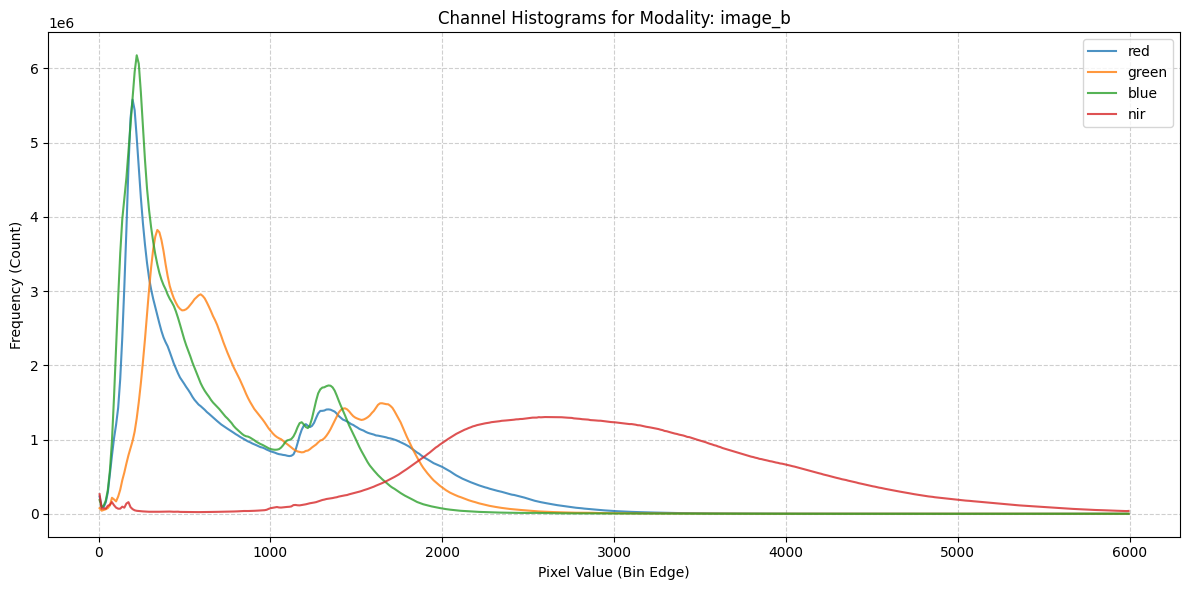

In [5]:
fig = plot_channel_histograms(STATS_SATMAE_PATH)

### Target Statistics

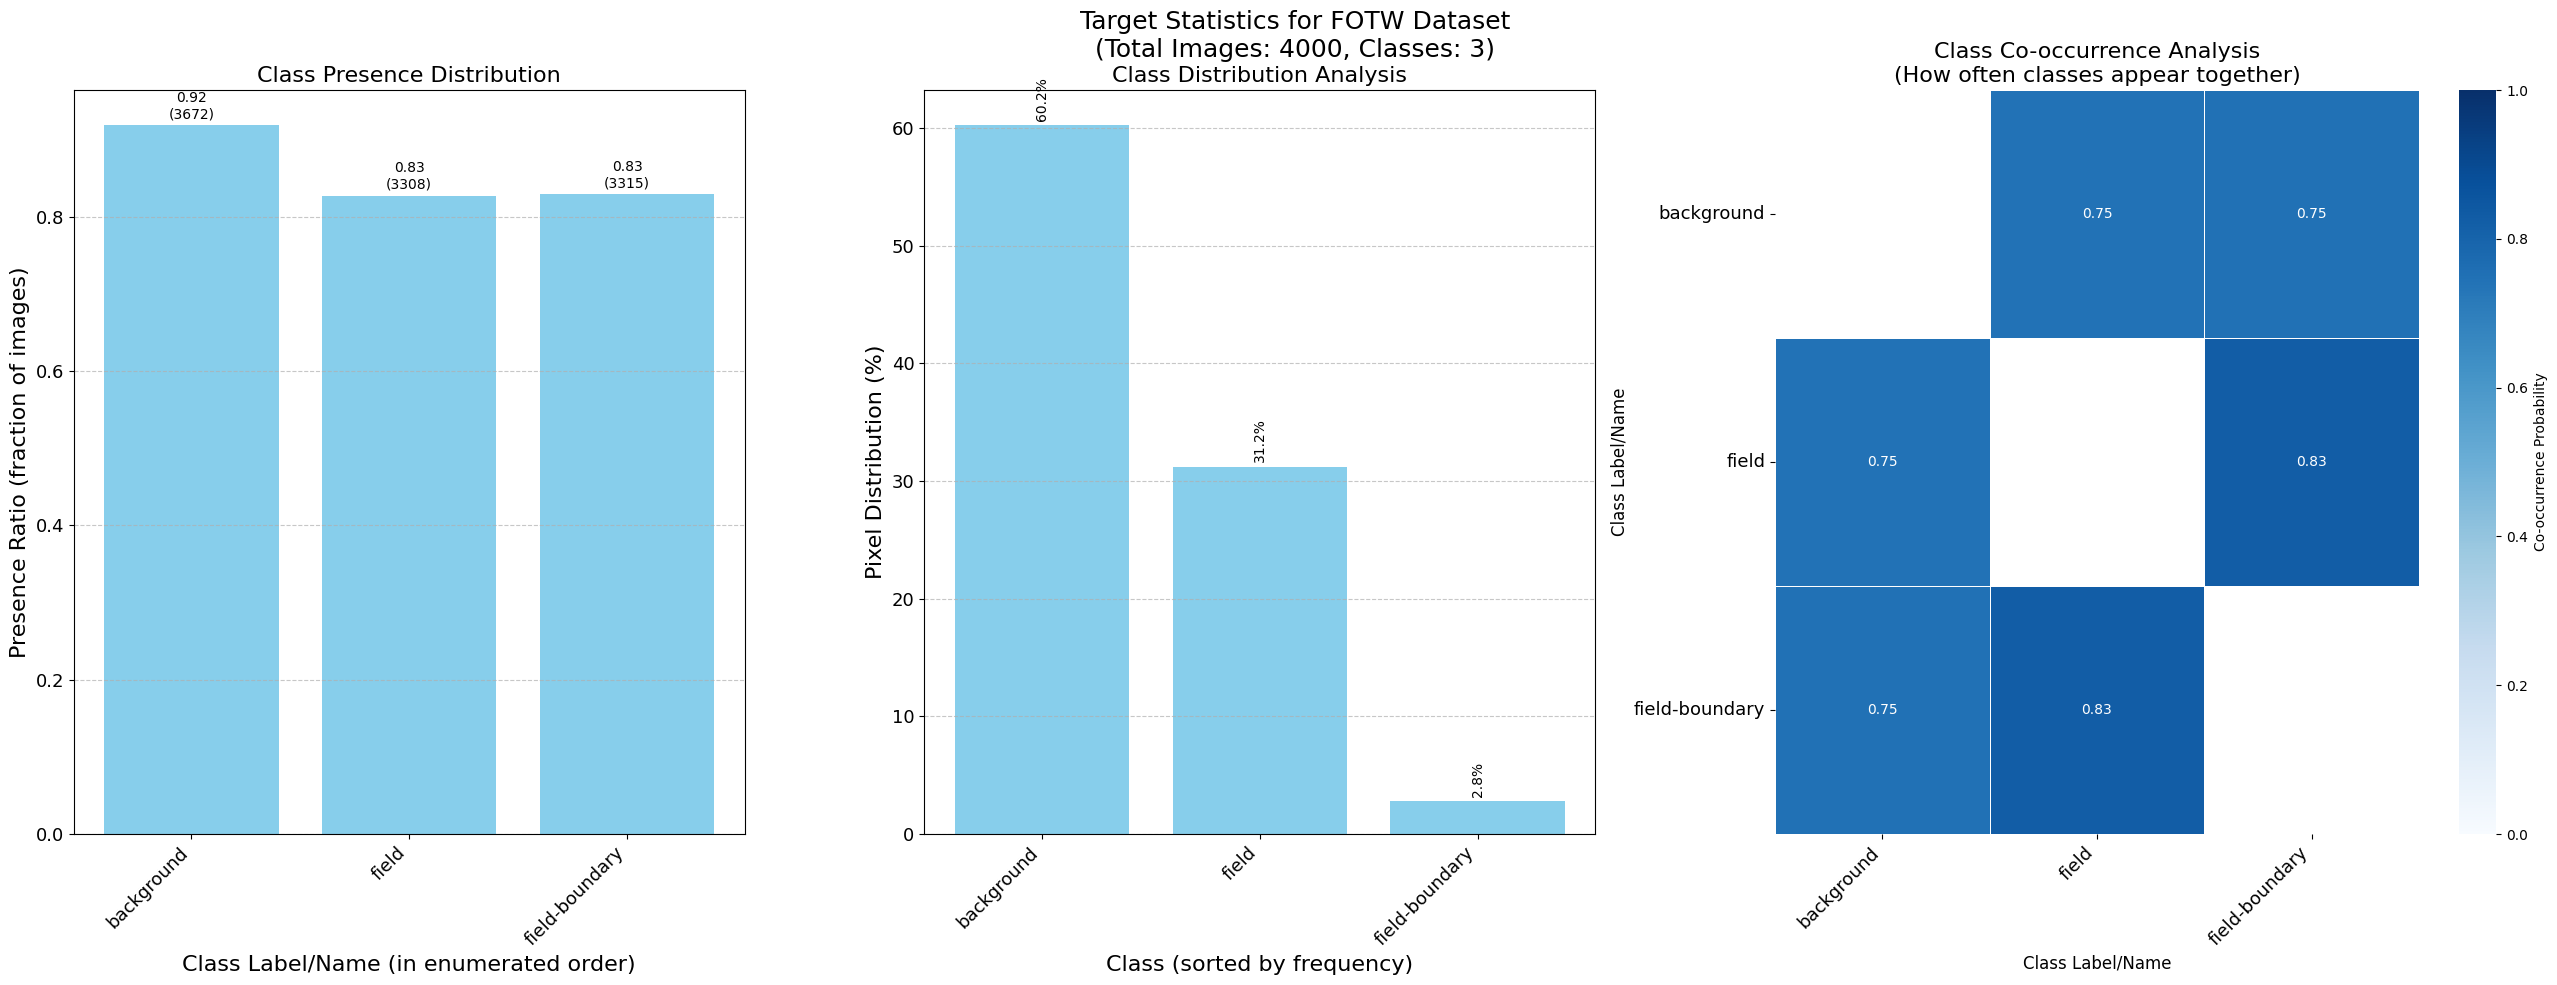

In [6]:
figs = visualize_segmentation_target_statistics(STATS_SATMAE_PATH, "FOTW")

### Raw Batch Statistics

[<Figure size 1200x500 with 1 Axes>, <Figure size 1200x500 with 1 Axes>]

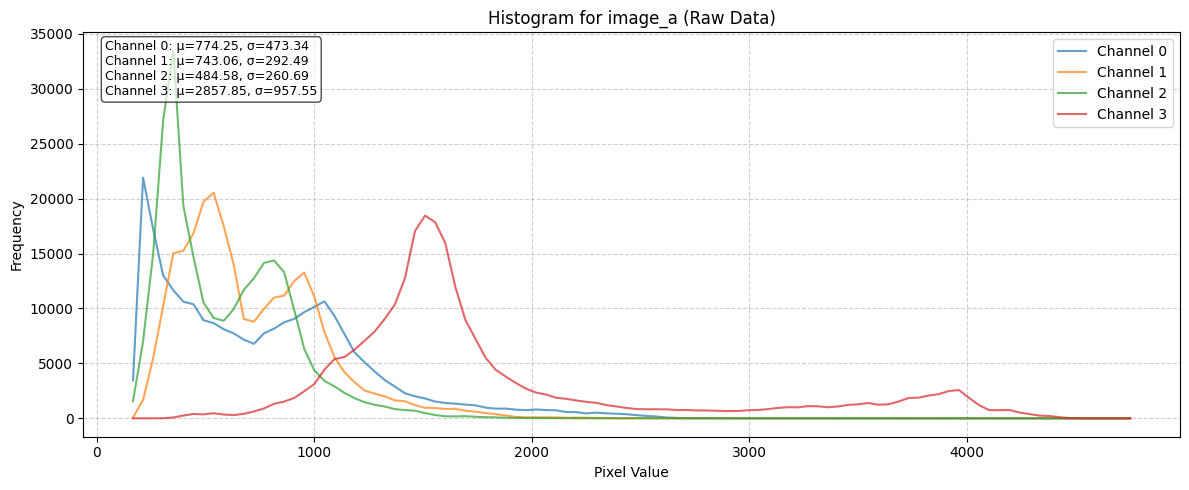

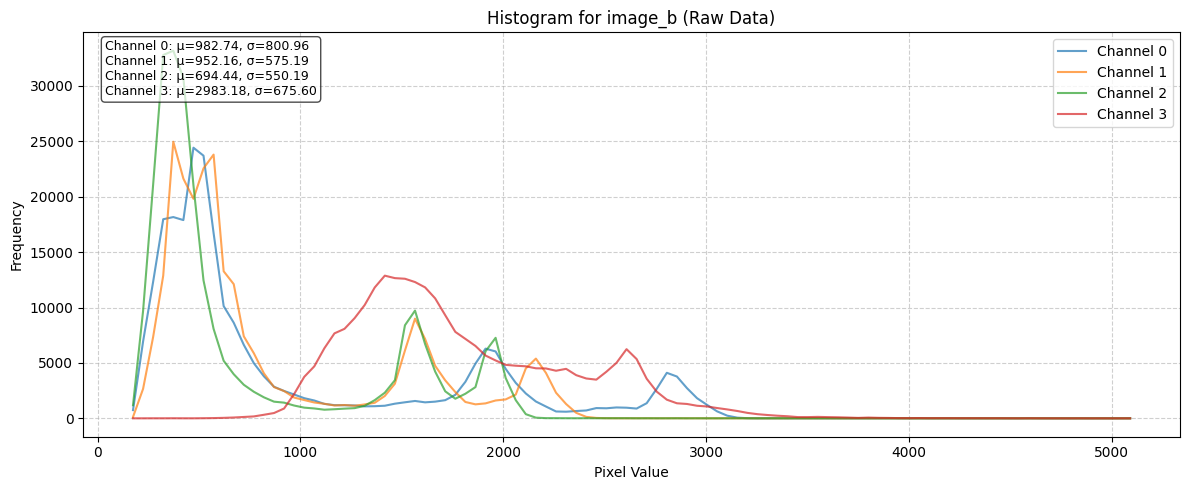

In [7]:
# Get a batch of data from the dataloader
train_dataloader = datamodule.train_dataloader()
raw_batch = next(iter(train_dataloader))

raw_batch_stats = compute_batch_histograms(raw_batch, n_bins=100)


raw_figs = plot_batch_histograms(
    raw_batch_stats, band_order, title_suffix=" (Raw Data)"
)
raw_figs

## Effect of different Normalization Schemes

In [8]:
zscore_normalizer = ZScoreNormalizer(STATS_CLIP_RESCALE_PATH, band_order)
satmae_normalizer = SatMAENormalizer(STATS_SATMAE_PATH, band_order)

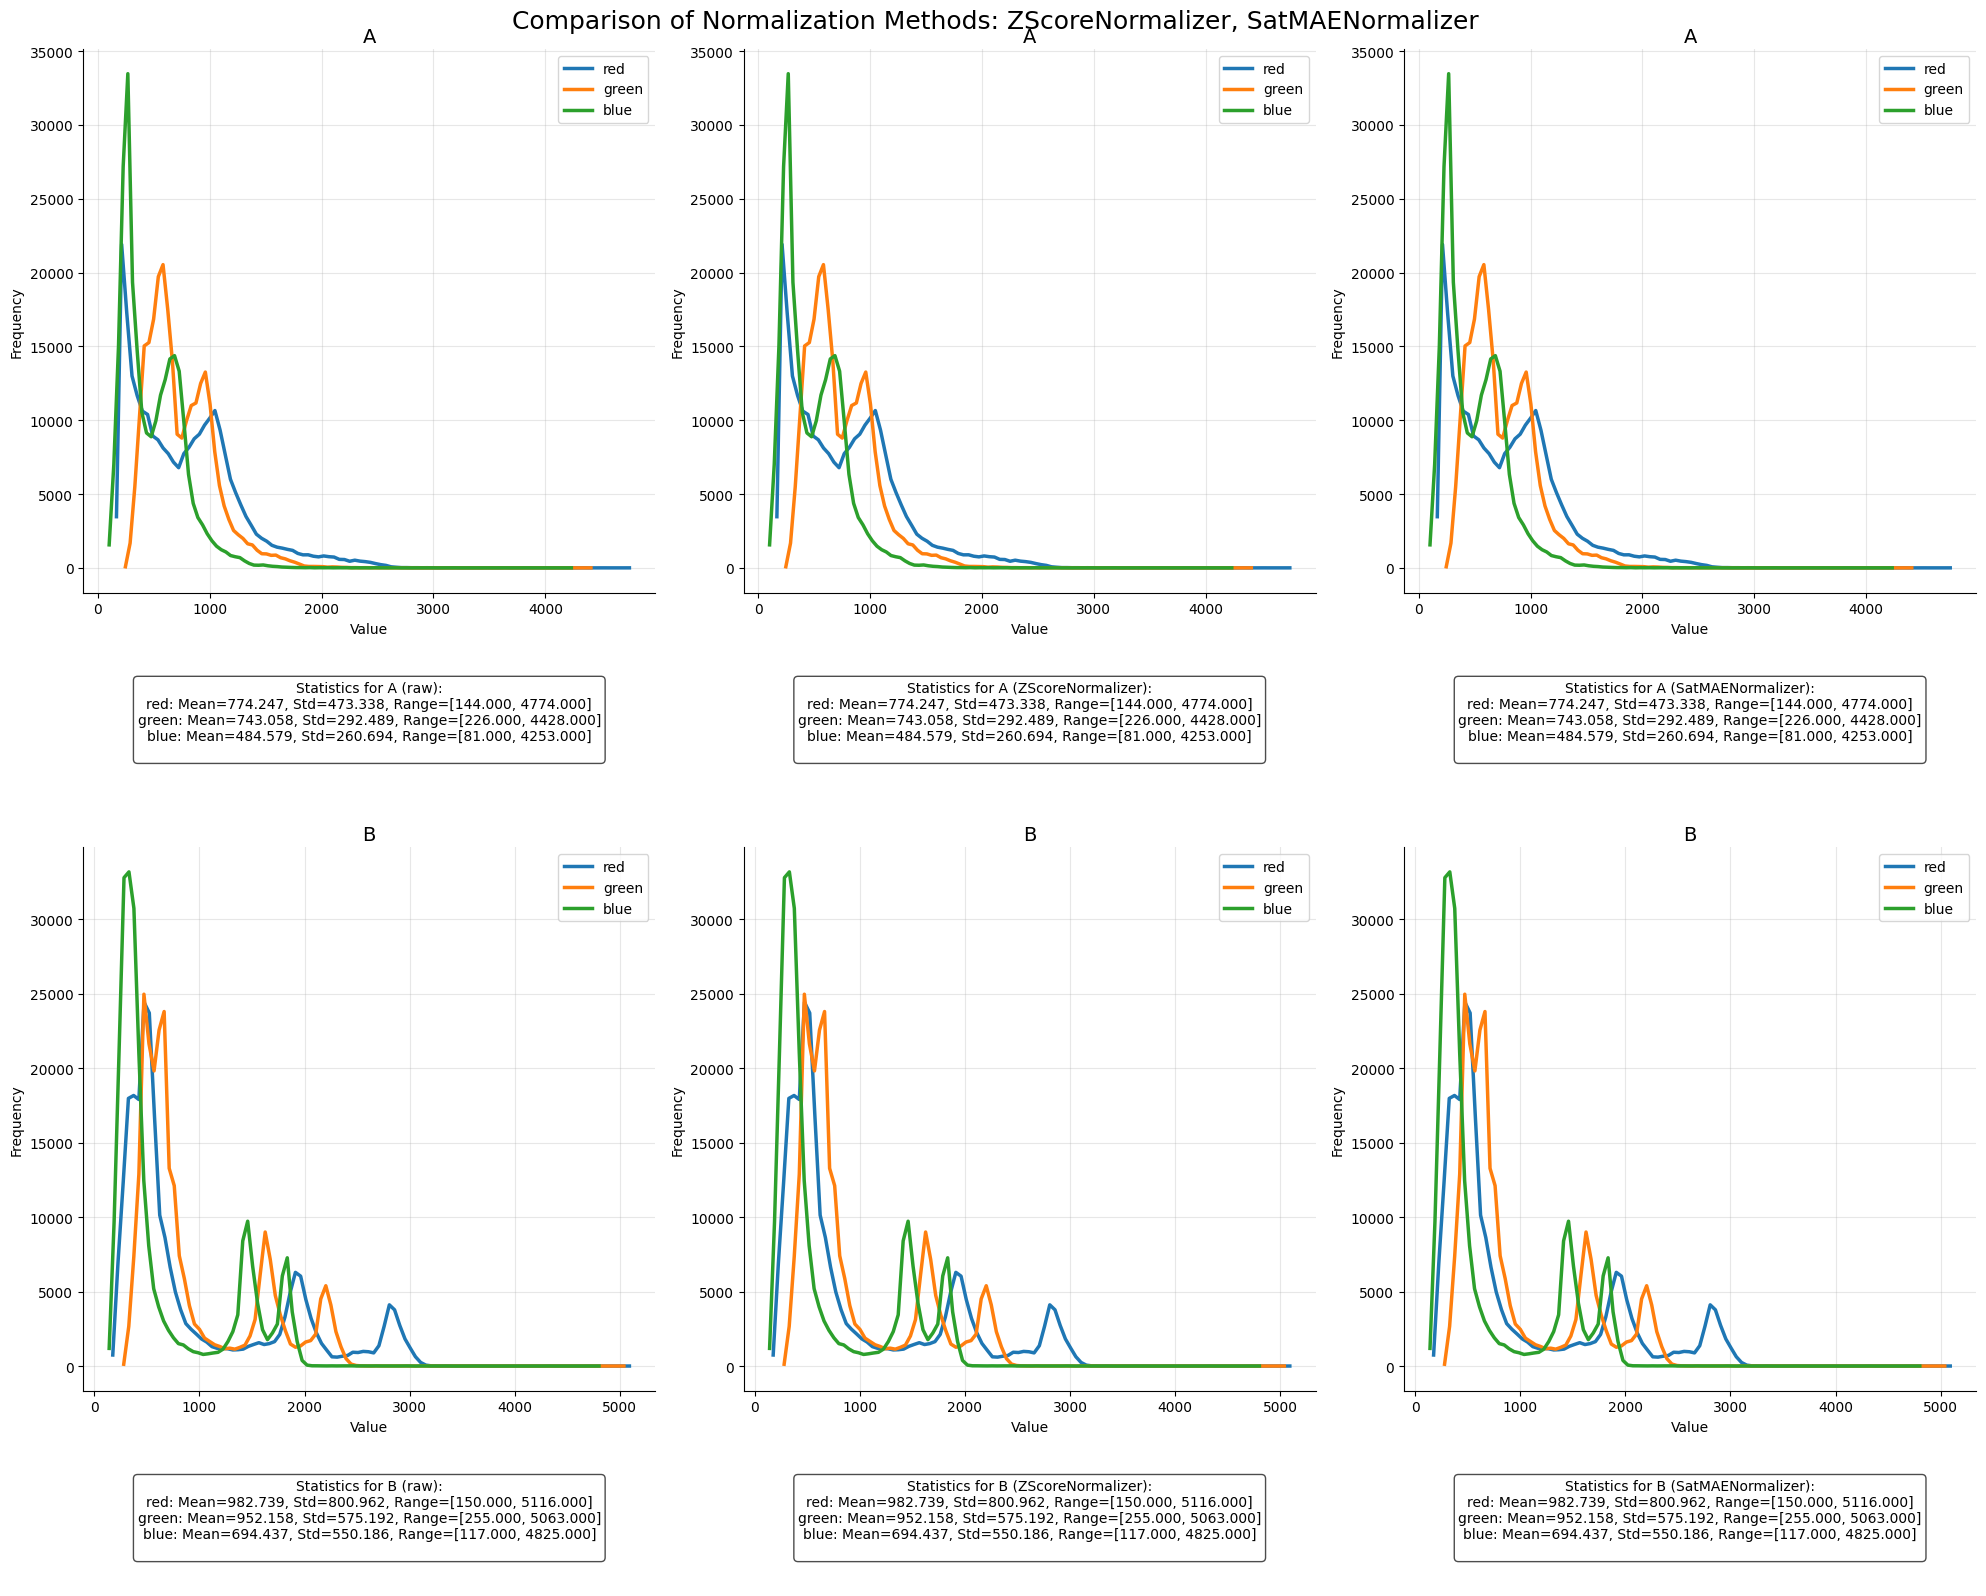

In [9]:
norm_fig, normalized_batches = compare_normalization_methods(
    raw_batch, [zscore_normalizer, satmae_normalizer], datamodule
)

## Visualize Batch Data

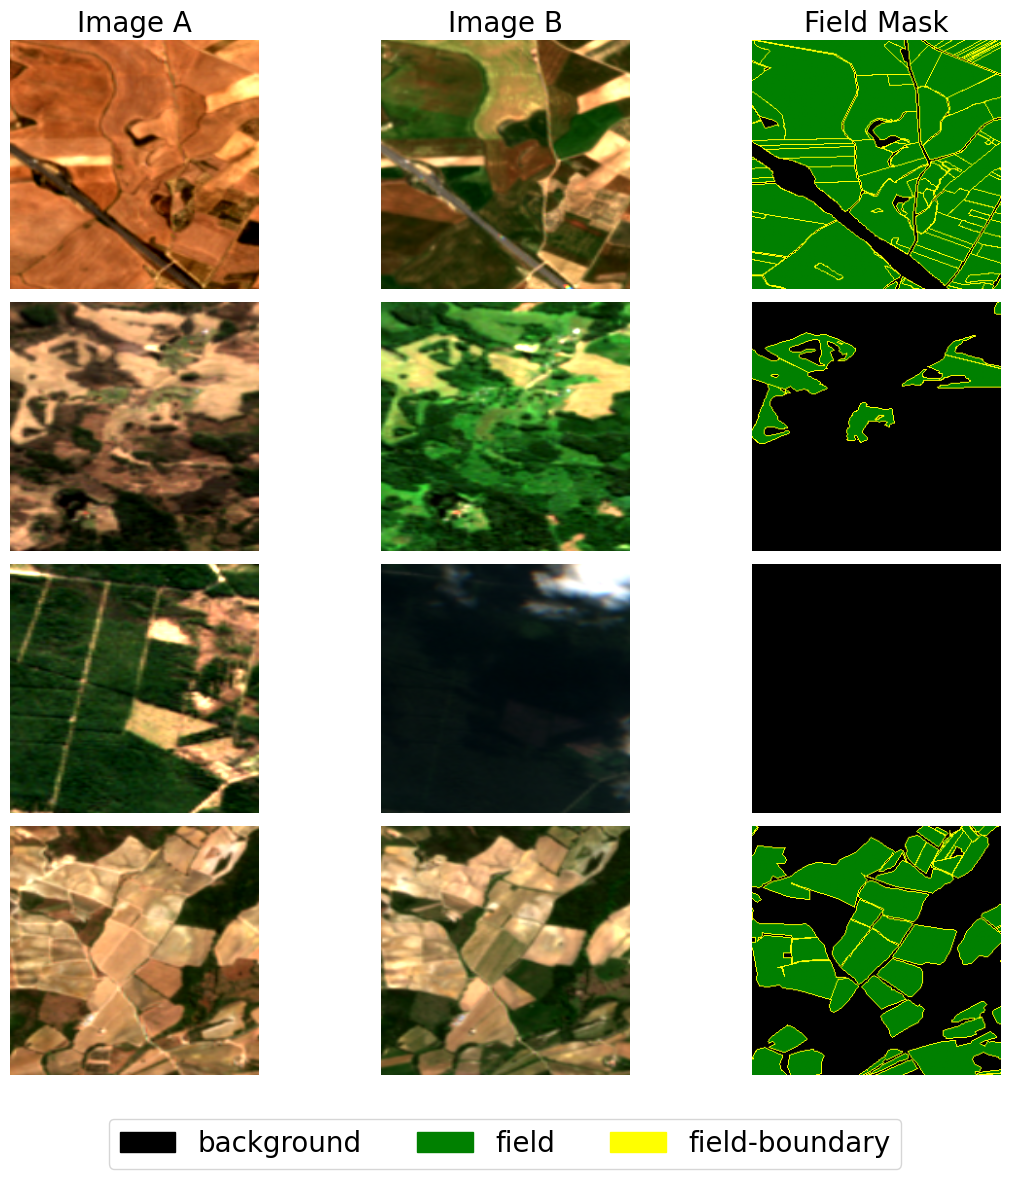

In [10]:
fig, batch = datamodule.visualize_batch()